In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [5]:
data = fetch_california_housing()
X, y = data.data, data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

In [6]:
class CaliforniaHousingNN(nn.Module):
    def __init__(self, input=8, hidden=[512, 1024], output=1, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input, hidden[0])
        self.bn1 = nn.BatchNorm1d(hidden[0])
        self.fc2 = nn.Linear(hidden[0], hidden[1])
        self.bn2 = nn.BatchNorm1d(hidden[1])
        self.fc3 = nn.Linear(hidden[1], output)
        self.relu = nn.ReLU()
        self.dropout= nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

Epoch 1, Loss 0.8403
Epoch 2, Loss 0.5279
Epoch 3, Loss 0.4922
Epoch 4, Loss 0.4695
Epoch 5, Loss 0.4396
Epoch 6, Loss 0.4369
Epoch 7, Loss 0.4174
Epoch 8, Loss 0.3987
Epoch 9, Loss 0.4016
Epoch 10, Loss 0.3852
Epoch 11, Loss 0.3793
Epoch 12, Loss 0.3778
Epoch 13, Loss 0.3788
Epoch 14, Loss 0.3698
Epoch 15, Loss 0.3672
Epoch 16, Loss 0.3708
Epoch 17, Loss 0.3651
Epoch 18, Loss 0.3616
Epoch 19, Loss 0.3547
Epoch 20, Loss 0.3550
Epoch 21, Loss 0.3507
Epoch 22, Loss 0.3491
Epoch 23, Loss 0.3461
Epoch 24, Loss 0.3448
Epoch 25, Loss 0.3455
Epoch 26, Loss 0.3470
Epoch 27, Loss 0.3437
Epoch 28, Loss 0.3302
Epoch 29, Loss 0.3355
Epoch 30, Loss 0.3420
Epoch 31, Loss 0.3327
Epoch 32, Loss 0.3360
Epoch 33, Loss 0.3507
Epoch 34, Loss 0.3290
Epoch 35, Loss 0.3317
Epoch 36, Loss 0.3314
Epoch 37, Loss 0.3299
Epoch 38, Loss 0.3352
Epoch 39, Loss 0.3260
Epoch 40, Loss 0.3221
Epoch 41, Loss 0.3233
Epoch 42, Loss 0.3267
Epoch 43, Loss 0.3178
Epoch 44, Loss 0.3294
Epoch 45, Loss 0.3194
Epoch 46, Loss 0.31

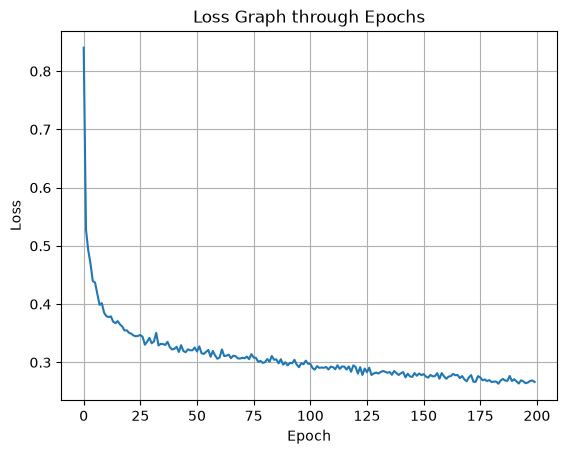

In [7]:
model = CaliforniaHousingNN()

lf = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

train_losses = []

epochs = 200

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = lf(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch + 1}, Loss {avg_loss:.4f}")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Graph through Epochs")
plt.grid(True)
plt.show()

In [8]:
def eval_regression(model, data_loader):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)  # MSE
            total_loss += loss.item() * y_batch.size(0)
            total_samples += y_batch.size(0)
    
    mse = total_loss / total_samples
    rmse = mse ** 0.5
    return mse, rmse

criterion = nn.MSELoss()
mse, rmse = eval_regression(model, test_loader)
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 0.2563
RMSE: 0.5063


In [ ]:
torch.save(model.state_dict(), 'california.pth')

RuntimeError: Parent directory ./models does not exist.